<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Machine-Learning/blob/main/Manufacturing_Predicition_Using_Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

practical-2(b) polynomial regression on manufacturing datset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Step 1: Import the dataset from CSV
df = pd.read_csv('manufacturing.csv')

In [ ]:
# Step 2: Display the dataset
print("Dataset:")
print(df)

Dataset:
      Temperature (°C)  Pressure (kPa)  Temperature x Pressure  \
0           209.762701        8.050855             1688.769167   
1           243.037873       15.812068             3842.931469   
2           220.552675        7.843130             1729.823314   
3           208.976637       23.786089             4970.736918   
4           184.730960       15.797812             2918.345014   
...                ...             ...                     ...   
3952        156.811578       21.794290             3417.596965   
3953        197.850406        8.291704             1640.516924   
3954        241.357144       16.391910             3956.304672   
3955        209.040239       23.809936             4977.234763   
3956        163.359996       24.332133             3974.897121   

      Material Fusion Metric  Material Transformation Metric  Quality Rating  
0               44522.217074                    9.229576e+06       99.999971  
1               63020.764997            

In [ ]:
# Step 3: Data Preprocessing
# Check for missing values
print("Missing values in the dataset:")
print(df.isnull().sum())

Missing values in the dataset:
Temperature (°C)                  0
Pressure (kPa)                    0
Temperature x Pressure            0
Material Fusion Metric            0
Material Transformation Metric    0
Quality Rating                    0
dtype: int64


In [ ]:
# If there were any missing values, we could handle them by dropping or filling them.
# Here we will just drop rows with missing values (if any).
df = df.dropna()

In [ ]:
# Step 4: Prepare the features (Temperature) and target variable (Ice Cream Sales)
X = df['Temperature (°C)'].values.reshape(-1, 1) # Independent variable (Temperature)
y = df['Quality Rating'] # Dependent variable (Ice Cream Sales)

In [ ]:
# Step 5: Transform the features into polynomial features (degree 3)
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)


In [ ]:
# Step 6: Create and fit the Polynomial Regression model
poly_reg_model = LinearRegression()
poly_reg_model.fit(X_poly, y)

LinearRegression()

In [ ]:
# Step 7: Predict the results using the polynomial regression model
predictions = poly_reg_model.predict(X_poly)

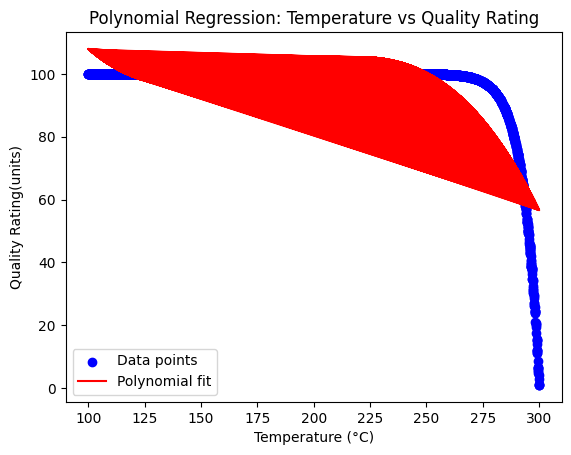

In [ ]:
# Step 8: Plot the polynomial regression curve
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions, color='red', label='Polynomial fit')
plt.xlabel('Temperature (°C)')
plt.ylabel('Quality Rating(units)')
plt.title('Polynomial Regression: Temperature vs Quality Rating')
plt.legend()
plt.show()


In [ ]:
# Step 9: Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Step 10: Evaluate the model (optional)
y_pred = poly_reg_model.predict(poly.transform(X_test))
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 63.0588045842741
R-squared: 0.6911162525711699
